[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SubSurfObs/observatory_notebooks/blob/main/01_fdsn_access/index.ipynb)

# 01 — Multi-Network FDSN Data Access

This notebook demonstrates how to query station metadata and download seismic waveforms
from the University of Melbourne seismic network (VW) and the Seismology Research Centre
network (OZ) using FDSN web services and ObsPy.

**Worked example:** Mw ~3 earthquake near Moe, Victoria, 3 February 2026.

**Output:** waveform and inventory files saved to `data/` for use by subsequent notebooks.


<table style="border:1px solid #BFC3D1;border-radius:6px;padding:0.5rem 1rem;margin-bottom:1rem;font-size:0.9em;background:#f9f9fb;border-collapse:separate;">
<tr><td style="padding:2px 12px 2px 0"><strong>Authors</strong></td><td>Dan Sandiford&nbsp;<a href="https://orcid.org/0000-0002-2207-6837"><img src="https://orcid.org/sites/default/files/images/orcid_16x16.png" alt="ORCID" style="vertical-align:middle"> 0000-0002-2207-6837</a></td></tr>
<tr><td style="padding:2px 12px 2px 0"><strong>Institution</strong></td><td>University of Melbourne — Subsurface Observatory</td></tr>
<tr><td style="padding:2px 12px 2px 0"><strong>Funding</strong></td><td>AuScope / National Collaborative Research Infrastructure Strategy (NCRIS)</td></tr>
<tr><td style="padding:2px 12px 2px 0"><strong>Data</strong></td><td>VW network &middot; DOI <a href="https://doi.org/10.7914/8csc-8z27">10.7914/8csc-8z27</a></td></tr>
<tr><td style="padding:2px 12px 2px 0"><strong>Notebook DOI</strong></td><td><em>in preparation (Zenodo)</em></td></tr>
<tr><td style="padding:2px 12px 2px 0"><strong>Licence</strong></td><td><a href="https://creativecommons.org/licenses/by/4.0/">CC BY 4.0</a></td></tr>
</table>

In [ ]:
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    import subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install',
                    'obspy', 'folium', 'pandas'], check=True)
    subprocess.run(['wget', '-q',
        'https://raw.githubusercontent.com/SubSurfObs/observatory_notebooks/main/utils.py'],
        check=True)


In [1]:
from pathlib import Path
import sys

for p in [Path.cwd().parent, Path.cwd()]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import folium
from obspy import UTCDateTime
import matplotlib.pyplot as plt

from utils import (
    Provider, collect_stations_and_waveforms,
    FDSN_UOM, FDSN_AUSPASS, FDSN_RS, FDSN_IRIS,
)
print('Imports OK')


Imports OK


In [2]:
# Moe, Victoria sequence — 3 Feb 2026
T_START    = UTCDateTime('2026-02-03T06:00:00')
DURATION   = 10 * 60   # seconds
T_END      = T_START + DURATION

SEARCH_LAT = -38.3
SEARCH_LON =  146.6
MAX_RADIUS =  1.5    # degrees
NETWORKS   = ['VW', 'OZ', 'AM']   # AM = RaspberryShake

print(f'Window: {T_START}  ->  {T_END}  ({DURATION} s)')


Window: 2026-02-03T08:11:40.000000Z  ->  2026-02-03T08:13:00.000000Z  (80 s total)


## Station inventory

Query both providers for stations within `MAX_RADIUS` degrees of the event.
Networks are assigned to the first provider that serves them — UoM takes
priority for VW, AusPass for OZ.


In [3]:
providers = [
    Provider('UoM',     FDSN_UOM),
    Provider('AusPass', FDSN_AUSPASS),
    Provider('RS',      FDSN_RS),
    Provider('IRIS',    FDSN_IRIS),
]

st, selections = collect_stations_and_waveforms(
    providers=providers,
    requested_networks=NETWORKS,
    latitude=SEARCH_LAT,
    longitude=SEARCH_LON,
    maxradius=MAX_RADIUS,
    starttime=T_START,
    endtime=T_END,
    channel='*H*,*N*',
    attach_response=True,
)

from obspy.core.inventory import Inventory
inv_all = Inventory()
for sel in selections.values():
    inv_all += sel.inventory

print(f'Stations: {len(list(inv_all.get_contents()["stations"]))}  |  Traces: {len(st)}')
for name, sel in selections.items():
    print(f'  {name}: networks={sel.networks}, stations={sel.stations}')


/Users/DSAND/projects/SubSurfObs/SubsurfaceObservatory/notebooks/utils.py:187: ObsPyDeprecationWarning: attach_response is deprecated and will be removed in a future release. Use remove_response() instead.
  st = client.get_waveforms(
/Users/DSAND/projects/SubSurfObs/SubsurfaceObservatory/notebooks/utils.py:187: ObsPyDeprecationWarning: attach_response is deprecated and will be removed in a future release. Use remove_response() instead.
  st = client.get_waveforms(


Stations: 37  |  Traces: 84
  UoM: networks=['VW'], stations=['BEST', 'BRIG', 'BRTH', 'CLIF', 'CRJN', 'DDWB', 'HDDL', 'LOCU', 'MARD', 'NARR', 'SGWU', 'SOMU', 'STBK', 'TEMP', 'TRPU', 'WDSD', 'WLSH']
  AusPass: networks=['OZ'], stations=['BUCHN', 'CCRM', 'CDNM', 'CURRY', 'DROM', 'DTMM', 'FRTM', 'GLMM', 'GRASY', 'HOPM', 'JEER', 'KORUM', 'MLWM', 'MR2A', 'ROWM', 'SRCHQ', 'TOT', 'WAMB', 'WILL', 'WORN']


In [4]:
# Interactive station map
lons, lats, labels, nets = [], [], [], []
for net in inv_all:
    for sta in net:
        if sta.longitude is not None and sta.latitude is not None:
            lons.append(sta.longitude)
            lats.append(sta.latitude)
            labels.append(sta.code)
            nets.append(net.code)

lat_c = sum(lats) / len(lats)
lon_c = sum(lons) / len(lons)

m = folium.Map(location=[lat_c, lon_c], zoom_start=7, tiles='OpenStreetMap')

NET_COLOUR = {'VW': 'darkblue', 'OZ': 'cadetblue', 'AM': 'purple'}
for lon, lat, label, net in zip(lons, lats, labels, nets):
    folium.Marker(
        location=[lat, lon],
        tooltip=f'{net}.{label}',
        icon=folium.Icon(color=NET_COLOUR.get(net, 'gray'), icon='signal'),
    ).add_to(m)

folium.Marker(
    location=[SEARCH_LAT, SEARCH_LON],
    tooltip='Search centre',
    icon=folium.Icon(color='red', icon='asterisk'),
).add_to(m)

m


## Waveforms

Select the vertical broadband channel for a quick overview plot.


/var/folders/50/4pb6cyv53tq0fmpjrm94qgdc0000gn/T/ipykernel_9299/3349468640.py:6: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


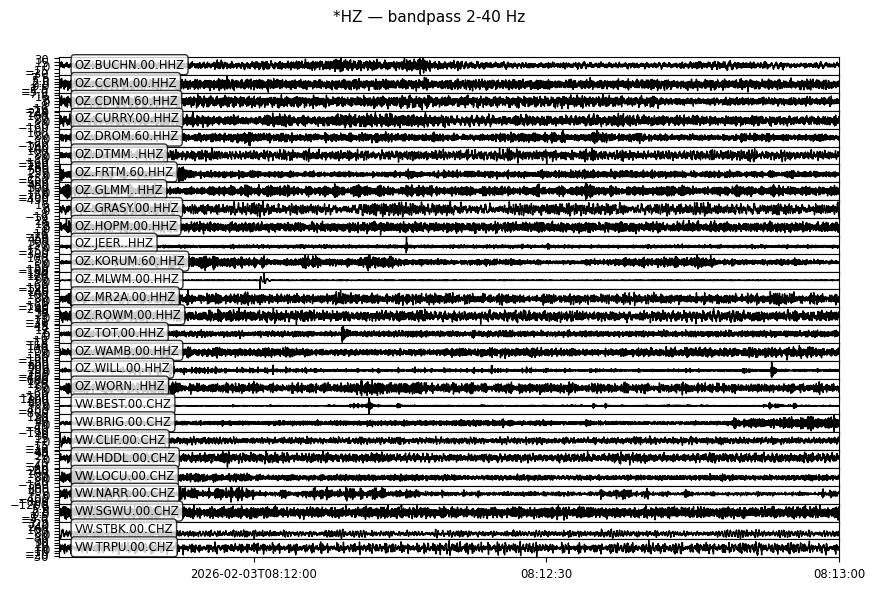

In [8]:
st_Z = st.select(channel='*HZ').copy()
st_Z.detrend('demean')
st_Z.filter('bandpass', freqmin=2.0, freqmax=40.0, corners=4)
fig = st_Z.plot(equal_scale=False, size=(900, 600), handle=True)
fig.suptitle('*HZ — bandpass 2-40 Hz', fontsize=11)
plt.tight_layout()
plt.show()


In [9]:
st_ = st.select(station='CLIF').copy()

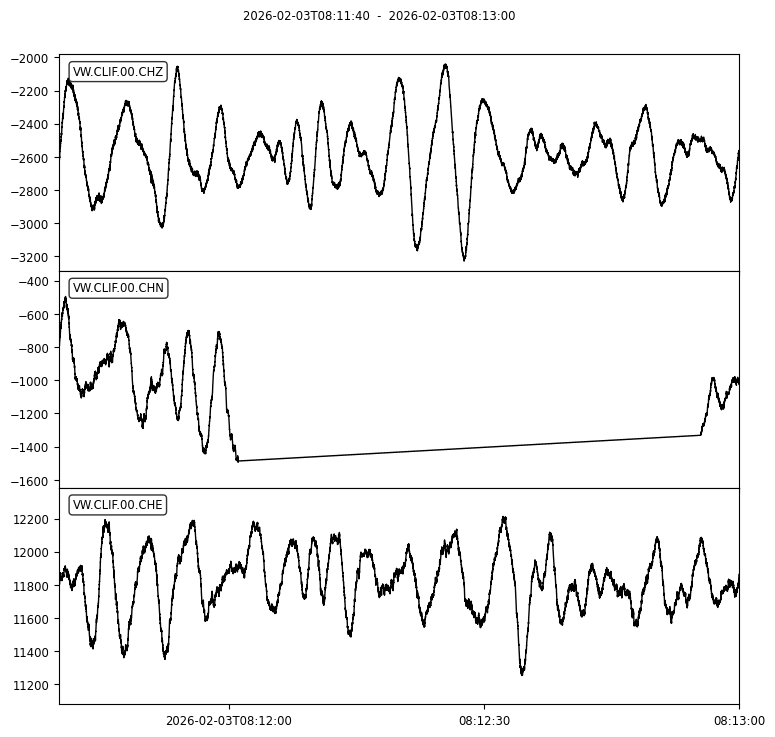

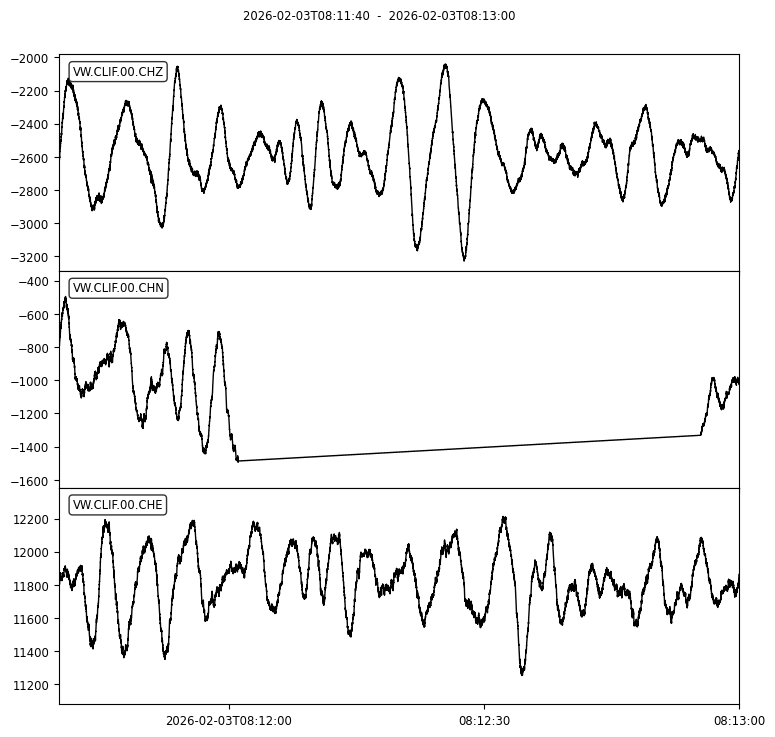

In [10]:
st_.plot()

## Save data

Downsample channels above 100 Hz before saving — this keeps the file small
while retaining all frequency content relevant for phase picking (PhaseNet
operates at 100 Hz anyway). Lower-rate channels are left unchanged.


In [7]:
data_dir = Path('data')
data_dir.mkdir(exist_ok=True)

st_save = st.copy()
for tr in st_save:
    if tr.stats.sampling_rate > 100:
        tr.resample(100.0)

mseed_path = data_dir / 'ex01.mseed'
xml_path   = data_dir / 'ex01.xml'

st_save.write(str(mseed_path), format='MSEED')
inv_all.write(str(xml_path),   format='STATIONXML')

print(f'Traces saved: {len(st_save)}')
print(f'{mseed_path}  ({mseed_path.stat().st_size / 1024**2:.1f} MB)')
print(f'{xml_path}    ({xml_path.stat().st_size / 1024:.0f} kB)')


Traces saved: 84
data/ex01.mseed  (2.4 MB)
data/ex01.xml    (171 kB)


---

**Next:** [02 — Phase Picking with SeisBench](../02_phase_picking/index.ipynb)

**Data source:** University of Melbourne Seismic Network (VW), DOI [10.7914/8csc-8z27](https://doi.org/10.7914/8csc-8z27).  
**Licence:** [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).
